# Supplemental code for Lesson 3

```bash
pip install numpy scikit-learn
```


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

In [53]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [54]:
df_clean = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

df_clean["FamilySize"] = df_clean["SibSp"] + df_clean["Parch"] + 1
df_clean["IsAlone"] = (df_clean["FamilySize"] == 1).astype(int)
df_clean["LogFare"] = np.log1p(df_clean["Fare"])

df_clean["Sex"] = df_clean["Sex"].map({"male": 0, "female": 1})
df_clean["Embarked"] = df_clean["Embarked"].map({"S": 0, "C": 1, "Q": 2})

df_clean = df_clean.drop(columns=["SibSp", "Parch", "Fare"])

print("Missing values remaining:", df_clean.isnull().sum().sum())
print("Shape after prep:", df_clean.shape)
df_clean.head()

Missing values remaining: 0
Shape after prep: (891, 8)


,Survived,Pclass,Sex,Age,Embarked,FamilySize,IsAlone,LogFare
0,0,3,0,22.0,0,2,0,2.110213
1,1,1,1,38.0,1,2,0,4.280593
2,1,3,1,26.0,0,1,1,2.188856
3,1,1,1,35.0,0,2,0,3.990834
4,0,3,0,35.0,0,1,1,2.202765


In [55]:
FEATURES = ["Pclass", "Sex", "Age", "LogFare", "Embarked", "FamilySize", "IsAlone"]
TARGET = "Survived"

X = df_clean[FEATURES]
y = df_clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")
print(f"\nSurvival rate in train: {y_train.mean():.3f}")
print(f"Survival rate in test:  {y_test.mean():.3f}")

Training set:  712 rows
Test set:      179 rows

Survival rate in train: 0.383
Survival rate in test:  0.385


In [56]:
majority_class = y_train.mode()[0]
naive_preds = np.full(len(y_test), majority_class)
naive_accuracy = accuracy_score(y_test, naive_preds)

print(f"Majority class: {majority_class} (Did not survive)")
print(f"Naive baseline accuracy: {naive_accuracy:.3f}")
print()
print("Interpretation: A model that always predicts 'did not survive'")
print(f"would be correct {naive_accuracy*100:.1f}% of the time — without learning anything.")
print(f"Our model must beat {naive_accuracy:.3f} to be worth using.")

Majority class: 0 (Did not survive)
Naive baseline accuracy: 0.615

Interpretation: A model that always predicts 'did not survive'
would be correct 61.5% of the time — without learning anything.
Our model must beat 0.615 to be worth using.


In [57]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

print("Model trained successfully.")

Model trained successfully.


In [58]:
y_pred  = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1] 

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("=" * 40)
print(f"  Naive Baseline Accuracy : {naive_accuracy:.3f}")
print(f"  Logistic Regression Acc : {acc:.3f}  (+{acc - naive_accuracy:.3f} vs baseline)")
print(f"  ROC-AUC Score           : {auc:.3f}")
print("=" * 40)
print(classification_report(y_test, y_pred, target_names=["Did Not Survive", "Survived"]))

  Naive Baseline Accuracy : 0.615
  Logistic Regression Acc : 0.804  (+0.190 vs baseline)
  ROC-AUC Score           : 0.841
                 precision    recall  f1-score   support

Did Not Survive       0.83      0.86      0.84       110
       Survived       0.77      0.71      0.74        69

       accuracy                           0.80       179
      macro avg       0.80      0.79      0.79       179
   weighted avg       0.80      0.80      0.80       179



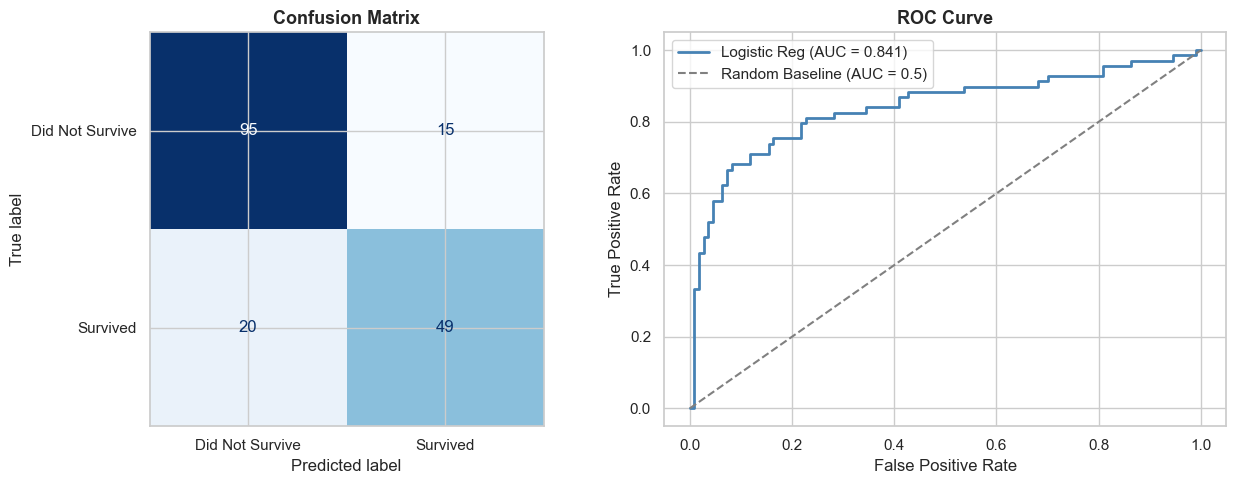

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Did Not Survive", "Survived"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix", fontsize=13, fontweight="bold")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color="steelblue", linewidth=2, label=f"Logistic Reg (AUC = {auc:.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Baseline (AUC = 0.5)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontsize=13, fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

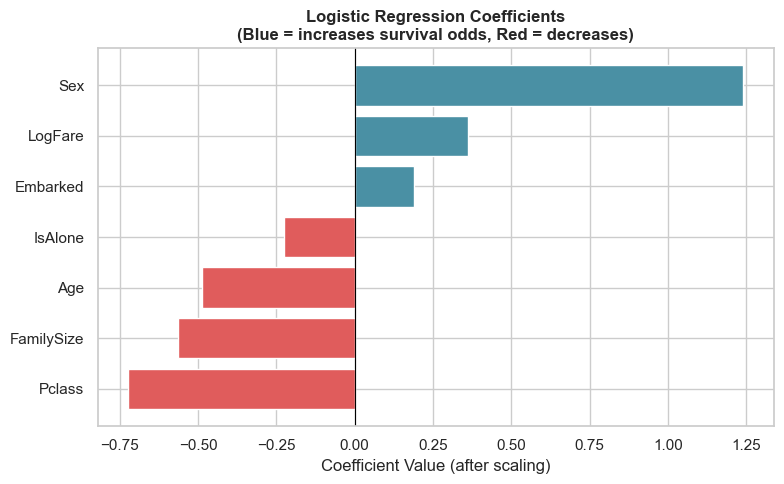

   Feature  Coefficient
    Pclass    -0.721796
FamilySize    -0.562586
       Age    -0.485877
   IsAlone    -0.224005
  Embarked     0.189855
   LogFare     0.360111
       Sex     1.239797


In [60]:
coef_df = pd.DataFrame({
    "Feature": FEATURES,
    "Coefficient": log_reg.coef_[0]
}).sort_values("Coefficient")

colors = ["#e05c5c" if c < 0 else "#4a90a4" for c in coef_df["Coefficient"]]

plt.figure(figsize=(8, 5))
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression Coefficients\n(Blue = increases survival odds, Red = decreases)",
          fontsize=12, fontweight="bold")
plt.xlabel("Coefficient Value (after scaling)")
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))

In [61]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42, max_iter=1000))
])
cv_scores = cross_val_score(pipe, X, y, cv=5, scoring="accuracy")

print("5-Fold Cross-Validation Accuracy:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.3f}")
print(f"\n  Mean:  {cv_scores.mean():.3f}")
print(f"  Std:   {cv_scores.std():.3f}")
print()
print("A low std (< 0.02) means the model is stable across different data splits.")

5-Fold Cross-Validation Accuracy:
  Fold 1: 0.760
  Fold 2: 0.787
  Fold 3: 0.781
  Fold 4: 0.798
  Fold 5: 0.826

  Mean:  0.790
  Std:   0.022

A low std (< 0.02) means the model is stable across different data splits.


In [62]:
import joblib
joblib.dump(pipe, "titanic_logistic_model.pkl")

['titanic_logistic_model.pkl']

# Part 2 — Linear Regression on House Prices

Go to this comp and join the comp:
kaggle.com/c/house-prices-advanced-regression-techniques

```bash
kaggle competitions download -c house-prices-advanced-regression-techniques
unzip house-prices-advanced-regression-techniques.zip
```

In [ ]:
houses = pd.read_csv("_house-prices/train.csv") 
houses.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [64]:

print("Shape:", houses.shape)
print("\nTarget — SalePrice:")
print(houses["SalePrice"].describe().apply(lambda x: f"${x:,.0f}"))

Shape: (1460, 81)

Target — SalePrice:
count      $1,460
mean     $180,921
std       $79,443
min       $34,900
25%      $129,975
50%      $163,000
75%      $214,000
max      $755,000
Name: SalePrice, dtype: str


In [65]:
pd.set_option('display.max_rows', None)
eda_summary = pd.DataFrame({
    "dtype": houses.dtypes,
    "num_unique": houses.nunique(),
    "num_missing": houses.isnull().sum(),
    "missing_pct": houses.isnull().mean() * 100
})

eda_summary.sort_values("num_unique")

,dtype,num_unique,num_missing,missing_pct
CentralAir,str,2,0,0.000000
Utilities,str,2,0,0.000000
Street,str,2,0,0.000000
Alley,str,2,1369,93.767123
BsmtHalfBath,int64,3,0,0.000000
LandSlope,str,3,0,0.000000
GarageFinish,str,3,81,5.547945
HalfBath,int64,3,0,0.000000
MasVnrType,str,3,872,59.726027
PavedDrive,str,3,0,0.000000


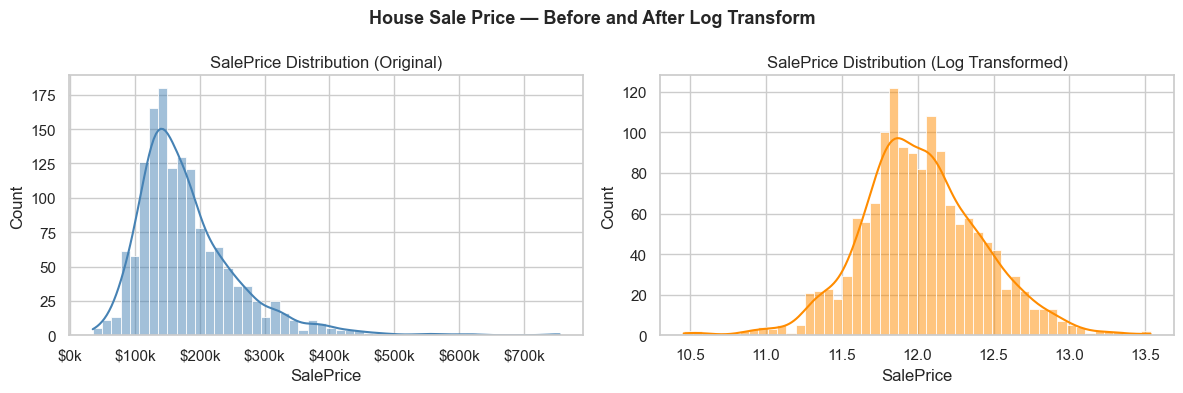

Original skew:          1.883
Log-transformed skew:   0.121

Linear regression assumes the target is roughly normally distributed.
High skew violates that assumption — log transform fixes it.


In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(houses["SalePrice"], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("SalePrice Distribution (Original)")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))

sns.histplot(np.log1p(houses["SalePrice"]), bins=50, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("SalePrice Distribution (Log Transformed)")

plt.suptitle("House Sale Price — Before and After Log Transform", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Original skew:          {houses['SalePrice'].skew():.3f}")
print(f"Log-transformed skew:   {np.log1p(houses['SalePrice']).skew():.3f}")
print()
print("Linear regression assumes the target is roughly normally distributed.")
print("High skew violates that assumption — log transform fixes it.")

In [67]:
HOUSE_FEATURES = [
    "GrLivArea",      
    "OverallQual",    
    "GarageCars",     
    "TotalBsmtSF",    
    "FullBath",       
    "YearBuilt",      
    "TotRmsAbvGrd",   
]

houses_clean = houses[HOUSE_FEATURES + ["SalePrice"]].dropna()

houses_clean["LogSalePrice"] = np.log1p(houses_clean["SalePrice"])

print(f"Rows after dropping any missing: {len(houses_clean)}")
houses_clean[HOUSE_FEATURES].describe().round(1)


Rows after dropping any missing: 1460


,GrLivArea,OverallQual,GarageCars,TotalBsmtSF,FullBath,YearBuilt,TotRmsAbvGrd
count,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0
mean,1515.5,6.1,1.8,1057.4,1.6,1971.3,6.5
std,525.5,1.4,0.7,438.7,0.6,30.2,1.6
min,334.0,1.0,0.0,0.0,0.0,1872.0,2.0
25%,1129.5,5.0,1.0,795.8,1.0,1954.0,5.0
50%,1464.0,6.0,2.0,991.5,2.0,1973.0,6.0
75%,1776.8,7.0,2.0,1298.2,2.0,2000.0,7.0
max,5642.0,10.0,4.0,6110.0,3.0,2010.0,14.0


/var/folders/lx/b4qt1jss59bdv0vzs87ly60h0000gn/T/ipykernel_26120/1751293269.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=corr_df, x="Correlation", y="Feature", palette="coolwarm")


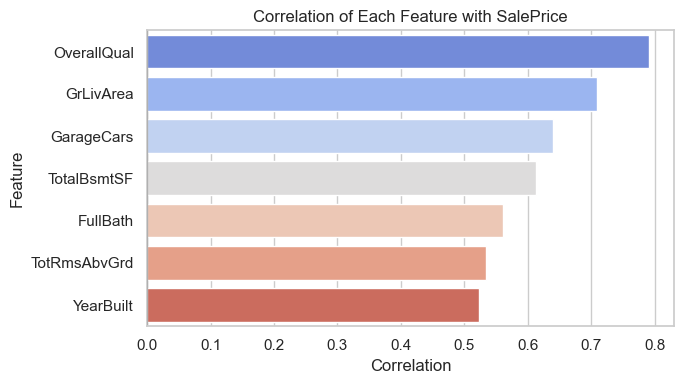

In [68]:
import seaborn as sns
corr_with_price = houses_clean[HOUSE_FEATURES + ["SalePrice"]].corr()["SalePrice"].drop("SalePrice").sort_values(ascending=False)

corr_df = corr_with_price.reset_index()
corr_df.columns = ["Feature", "Correlation"]

plt.figure(figsize=(7, 4))
sns.barplot(data=corr_df, x="Correlation", y="Feature", palette="coolwarm")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlation of Each Feature with SalePrice")
plt.tight_layout()
plt.show()

In [69]:
X_h = houses_clean[HOUSE_FEATURES]
y_h = houses_clean["LogSalePrice"]

X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42
)


mean_log_price = y_h_train.mean()
naive_preds_h  = np.full(len(y_h_test), mean_log_price)

naive_rmse = np.sqrt(mean_squared_error(y_h_test, naive_preds_h))
naive_rmse_dollars = np.expm1(mean_log_price + naive_rmse) - np.expm1(mean_log_price)

print(f"Naive baseline (predict mean log price):")
print(f"  RMSE (log scale):  {naive_rmse:.4f}")
print(f"  Approximate error in dollars: ${naive_rmse_dollars:,.0f}")


scaler_h = StandardScaler()
X_h_train_scaled = scaler_h.fit_transform(X_h_train)
X_h_test_scaled  = scaler_h.transform(X_h_test)

lin_reg = LinearRegression()
lin_reg.fit(X_h_train_scaled, y_h_train)

print("\nLinear regression trained.")

Naive baseline (predict mean log price):
  RMSE (log scale):  0.4332
  Approximate error in dollars: $91,002

Linear regression trained.


In [70]:
y_h_pred = lin_reg.predict(X_h_test_scaled)

rmse = np.sqrt(mean_squared_error(y_h_test, y_h_pred))
mae  = mean_absolute_error(y_h_test, y_h_pred)
r2   = r2_score(y_h_test, y_h_pred)

y_h_test_dollars = np.expm1(y_h_test)
y_h_pred_dollars = np.expm1(y_h_pred)
rmse_dollars = np.sqrt(mean_squared_error(y_h_test_dollars, y_h_pred_dollars))

print("=" * 50)
print(f"  Naive Baseline RMSE (log): {naive_rmse:.4f}")
print(f"  Linear Regression RMSE  : {rmse:.4f}  ({'-' if rmse < naive_rmse else '+'}{ abs(rmse - naive_rmse):.4f} vs baseline)")
print()
print(f"  MAE  (log scale): {mae:.4f}")
print(f"  R²   Score:       {r2:.3f}")
print("=" * 50)
print()
print("R² interpretation:")
print(f"  {r2:.3f} means the model explains {r2*100:.1f}% of the variance in house prices")
print("  R² of 1.0 = perfect. R² of 0.0 = as good as predicting the mean (our baseline).")

  Naive Baseline RMSE (log): 0.4332
  Linear Regression RMSE  : 0.1740  (-0.2592 vs baseline)

  MAE  (log scale): 0.1212
  R²   Score:       0.838

R² interpretation:
  0.838 means the model explains 83.8% of the variance in house prices
  R² of 1.0 = perfect. R² of 0.0 = as good as predicting the mean (our baseline).


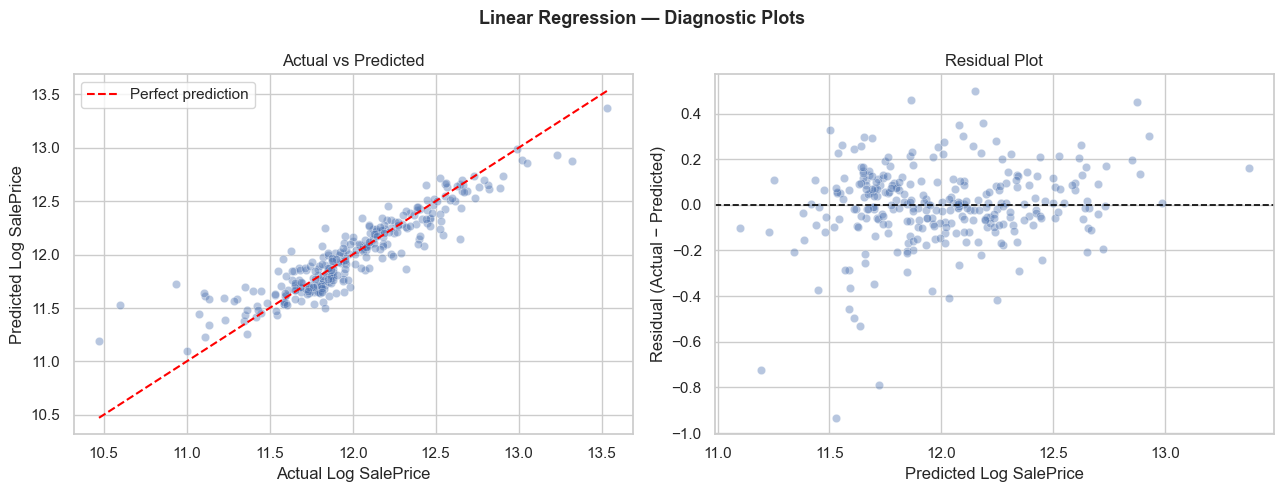

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

residuals = y_h_test - y_h_pred

sns.scatterplot(x=y_h_test, y=y_h_pred, alpha=0.4, ax=axes[0])
min_val, max_val = y_h_test.min(), y_h_test.max()
axes[0].plot([min_val, max_val], [min_val, max_val], color="red", linewidth=1.5, linestyle="--", label="Perfect prediction")
axes[0].set_xlabel("Actual Log SalePrice")
axes[0].set_ylabel("Predicted Log SalePrice")
axes[0].set_title("Actual vs Predicted")
axes[0].legend()

sns.scatterplot(x=y_h_pred, y=residuals, alpha=0.4, ax=axes[1])
axes[1].axhline(0, color="black", linewidth=1.2, linestyle="--")
axes[1].set_xlabel("Predicted Log SalePrice")
axes[1].set_ylabel("Residual (Actual − Predicted)")
axes[1].set_title("Residual Plot")

plt.suptitle("Linear Regression — Diagnostic Plots", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

/var/folders/lx/b4qt1jss59bdv0vzs87ly60h0000gn/T/ipykernel_26120/3144983526.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_h_df, x="Coefficient", y="Feature", palette="coolwarm")


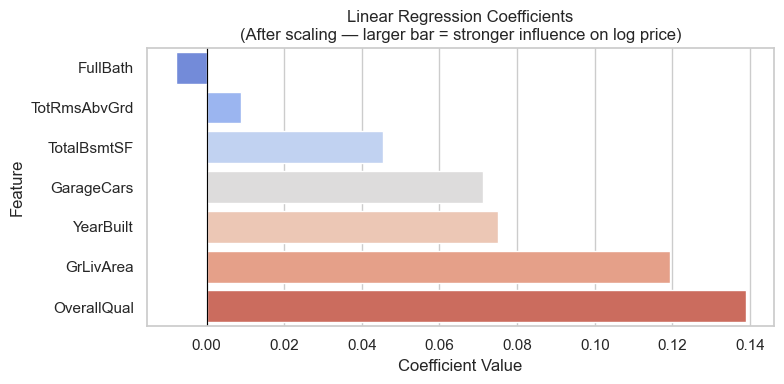

     Feature  Coefficient
    FullBath    -0.007960
TotRmsAbvGrd     0.008901
 TotalBsmtSF     0.045354
  GarageCars     0.071238
   YearBuilt     0.075124
   GrLivArea     0.119334
 OverallQual     0.138819

Intercept: 12.0307


In [72]:
coef_h_df = pd.DataFrame({
    "Feature": HOUSE_FEATURES,
    "Coefficient": lin_reg.coef_
}).sort_values("Coefficient")

plt.figure(figsize=(8, 4))
sns.barplot(data=coef_h_df, x="Coefficient", y="Feature", palette="coolwarm")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Linear Regression Coefficients\n(After scaling — larger bar = stronger influence on log price)")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

print(coef_h_df.to_string(index=False))
print(f"\nIntercept: {lin_reg.intercept_:.4f}")

In [ ]:
test = pd.read_csv("_house-prices/test.csv")
print(f"Test set shape: {test.shape}")

# Grab the same features we used for training
HOUSE_FEATURES = [
    "GrLivArea",      
    "OverallQual",    
    "GarageCars",     
    "TotalBsmtSF",    
    "FullBath",       
    "YearBuilt",      
    "TotRmsAbvGrd",   
]
X_test_submission = test[HOUSE_FEATURES].copy()
X_test_submission = X_test_submission.fillna(X_test_submission.median())

print(f"\nMissing values in test features:")
print(X_test_submission.isnull().sum())

X_test_submission_scaled = scaler_h.transform(X_test_submission)
log_predictions = lin_reg.predict(X_test_submission_scaled)
predicted_prices = np.expm1(log_predictions)

submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': predicted_prices
})

# Save to CSV for Kaggle submission
submission.to_csv('house_prices_submission.csv', index=False)

print(f"\n{'='*60}")
print(f"Predictions generated for {len(submission)} houses!")
print(f"{'='*60}")
print(f"\nPredicted Price Statistics:")
print(f"  Minimum:  ${predicted_prices.min():>12,.0f}")
print(f"  Median:   ${np.median(predicted_prices):>12,.0f}")
print(f"  Mean:     ${predicted_prices.mean():>12,.0f}")
print(f"  Maximum:  ${predicted_prices.max():>12,.0f}")
print(f"\nFirst 10 predictions:")
print(submission.head(10).to_string(index=False))
print(f"\n✓ Submission file saved as 'house_prices_submission.csv'")

Test set shape: (1459, 80)

Missing values in test features:
GrLivArea       0
OverallQual     0
GarageCars      0
TotalBsmtSF     0
FullBath        0
YearBuilt       0
TotRmsAbvGrd    0
dtype: int64

Predictions generated for 1459 houses!

Predicted Price Statistics:
  Minimum:  $      64,529
  Median:   $     159,998
  Mean:     $     176,516
  Maximum:  $   1,088,393

First 10 predictions:
  Id     SalePrice
1461 115225.223783
1462 147110.180538
1463 163027.557927
1464 180822.897650
1465 208014.809805
1466 177699.619980
1467 165224.947647
1468 172736.757234
1469 192802.923176
1470 116163.067293

✓ Submission file saved as 'house_prices_submission.csv'


# Submit to kaggle
```bash
kaggle competitions submit -c house-prices-advanced-regression-techniques -f house_prices_submission.csv -m "My submission"
```

# End of class acitivty - improve the current system by adding more relevant features

(1460, 81)


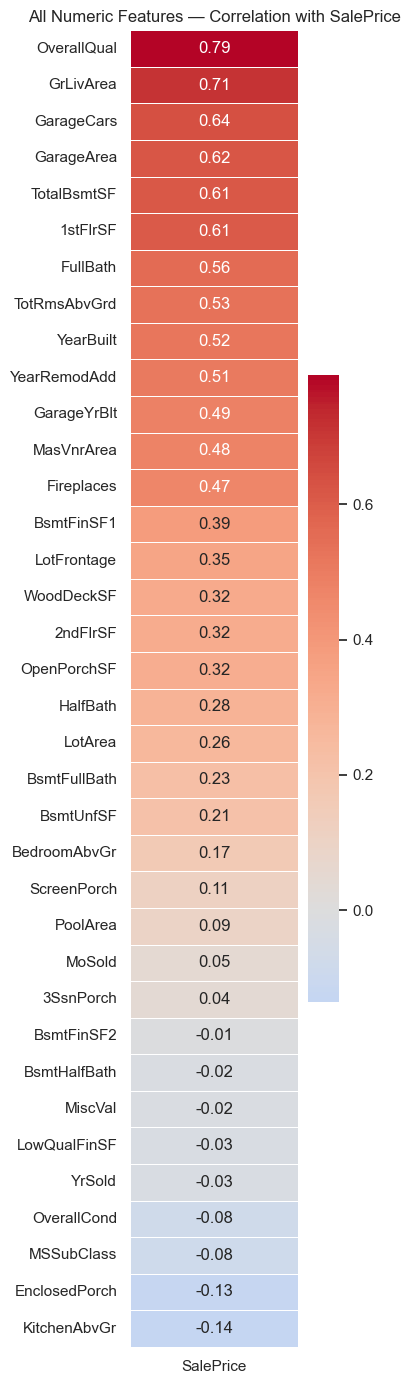

In [ ]:
houses = pd.read_csv("_house-prices/train.csv")
print(houses.shape)

numeric_cols = houses.select_dtypes(include="number").drop(columns=["Id"]).columns
corr_all = houses[numeric_cols].corr()[["SalePrice"]].drop("SalePrice").sort_values("SalePrice", ascending=False)

plt.figure(figsize=(4, 14))
sns.heatmap(corr_all, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("All Numeric Features — Correlation with SalePrice")
plt.tight_layout()
plt.show()

/var/folders/lx/b4qt1jss59bdv0vzs87ly60h0000gn/T/ipykernel_26120/560353837.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = houses.select_dtypes(include="object").columns.tolist()


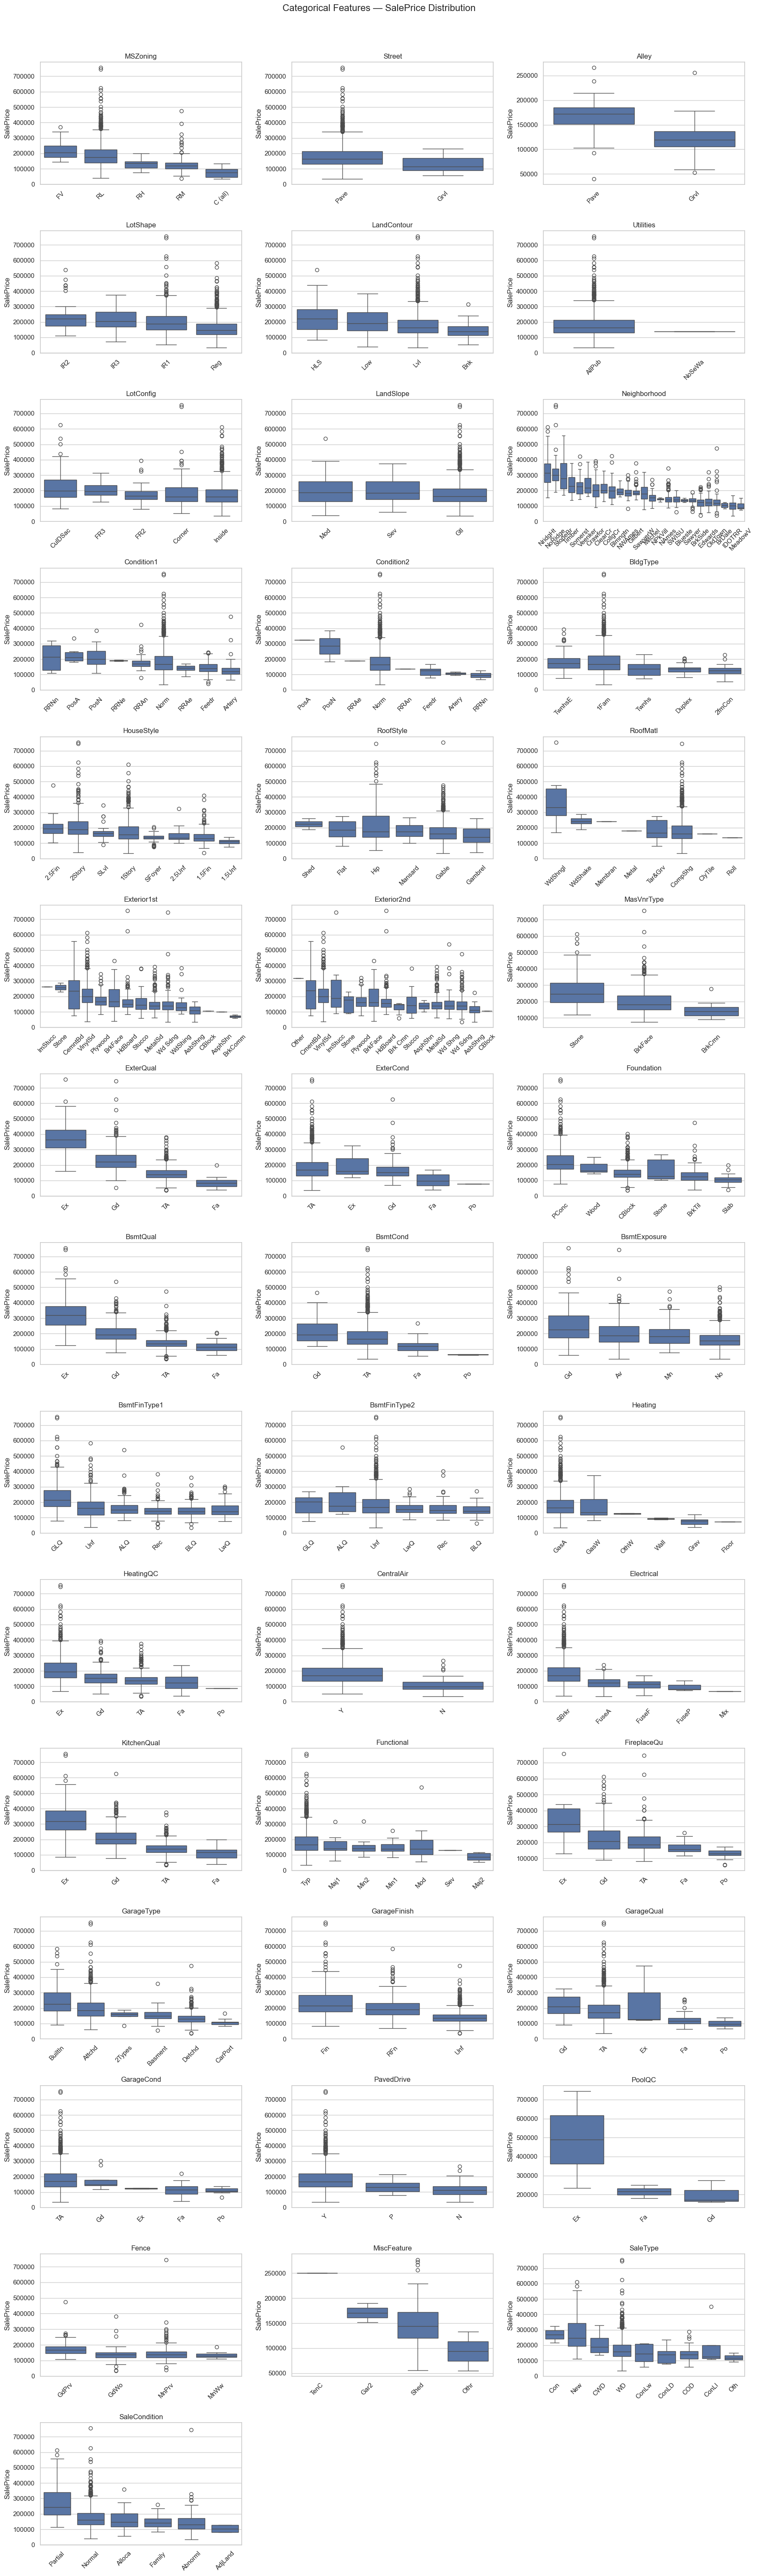

In [75]:
cat_cols = houses.select_dtypes(include="object").columns.tolist()

fig, axes = plt.subplots(len(cat_cols)//3 + 1, 3, figsize=(18, 60))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Sort by median price so the plot is easy to read
    order = houses.groupby(col)["SalePrice"].median().sort_values(ascending=False).index
    sns.boxplot(data=houses, x=col, y="SalePrice", order=order, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=45)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Categorical Features — SalePrice Distribution", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()